In [1]:
import numpy as np, matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib
import corner
import pickle
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")
import BaryonForge as bfg
import pyccl as ccl
from scipy.integrate import cumulative_trapezoid, simpson
from astropy import constants as con
import os
from scipy.stats import gaussian_kde
import h5py

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams.update(
    {
        'text.usetex': False,
        'font.family': 'stixgeneral',
        'mathtext.fontset': 'stix',
    }
)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['image.origin'] = 'lower'
sns.set_context('talk') 
# sns.set(font_scale=2)
sns.set(font_scale=1.75)
sns.set_palette('colorblind')
sns.set_style('ticks')
# plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'sans'
plt.rcParams['mathtext.it'] = 'sans:italic'
plt.rcParams['mathtext.bf'] = 'sans:bold'
plt.rcParams['pdf.fonttype']=42

import matplotlib as mpl

mpl.rcParams['axes.linewidth'] = 2
mpl.rcParams['xtick.major.width'] = 2
mpl.rcParams['ytick.major.width'] = 2
mpl.rcParams['xtick.minor.width'] = 1
mpl.rcParams['ytick.minor.width'] = 1
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 2.5
mpl.rcParams['ytick.minor.size'] = 2.5


## Cornerplots

In [2]:
def get_samples(mcmc_file):
    class RenameUnpickler(pickle.Unpickler):
        def find_class(self, module, name):
            if module.startswith("numpy._core"):
                module = module.replace("numpy._core", "numpy.core")
            return super().find_class(module, name)
    with open(mcmc_file, "rb") as f:
        results = RenameUnpickler(f).load()
    chain = results["chain"]
    samples = chain.reshape(-1, chain.shape[-1])
    # DMhost transformations
    DMhost_mean = np.exp(samples[:, -2] + ((samples[:, -1]**2)/2))
    DMhost_var = np.sqrt((np.exp(samples[:, -1]**2) - 1) * np.exp((2*samples[:, -2]) + (samples[:, -1]**2)))
    samples[:, -2] = DMhost_mean; samples[:, -1] = DMhost_var
    return samples

HMcode_samples = get_samples("data/frb_results/emcee_HMcode_extended.pkl")

BCEmu1_samples = get_samples("data/frb_results/emcee_BCEmu1_extended.pkl") # log_Mc

BCEmu4_samples = get_samples("data/frb_results/emcee_BCEmu4_extended.pkl") # log_Mc, theta_ej, mu_beta, delta

BCEmu5_samples = get_samples("data/frb_results/emcee_BCEmu5_extended_Chandraprior.pkl") # log_Mc, theta_ej, mu_beta, delta, eta

BCEmu7_samples = get_samples("data/frb_results/emcee_BCEmu7_extended_Chandraprior.pkl")[:, [0, 1, 3, 5, 6, 2, 4, 7, 8]]


Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


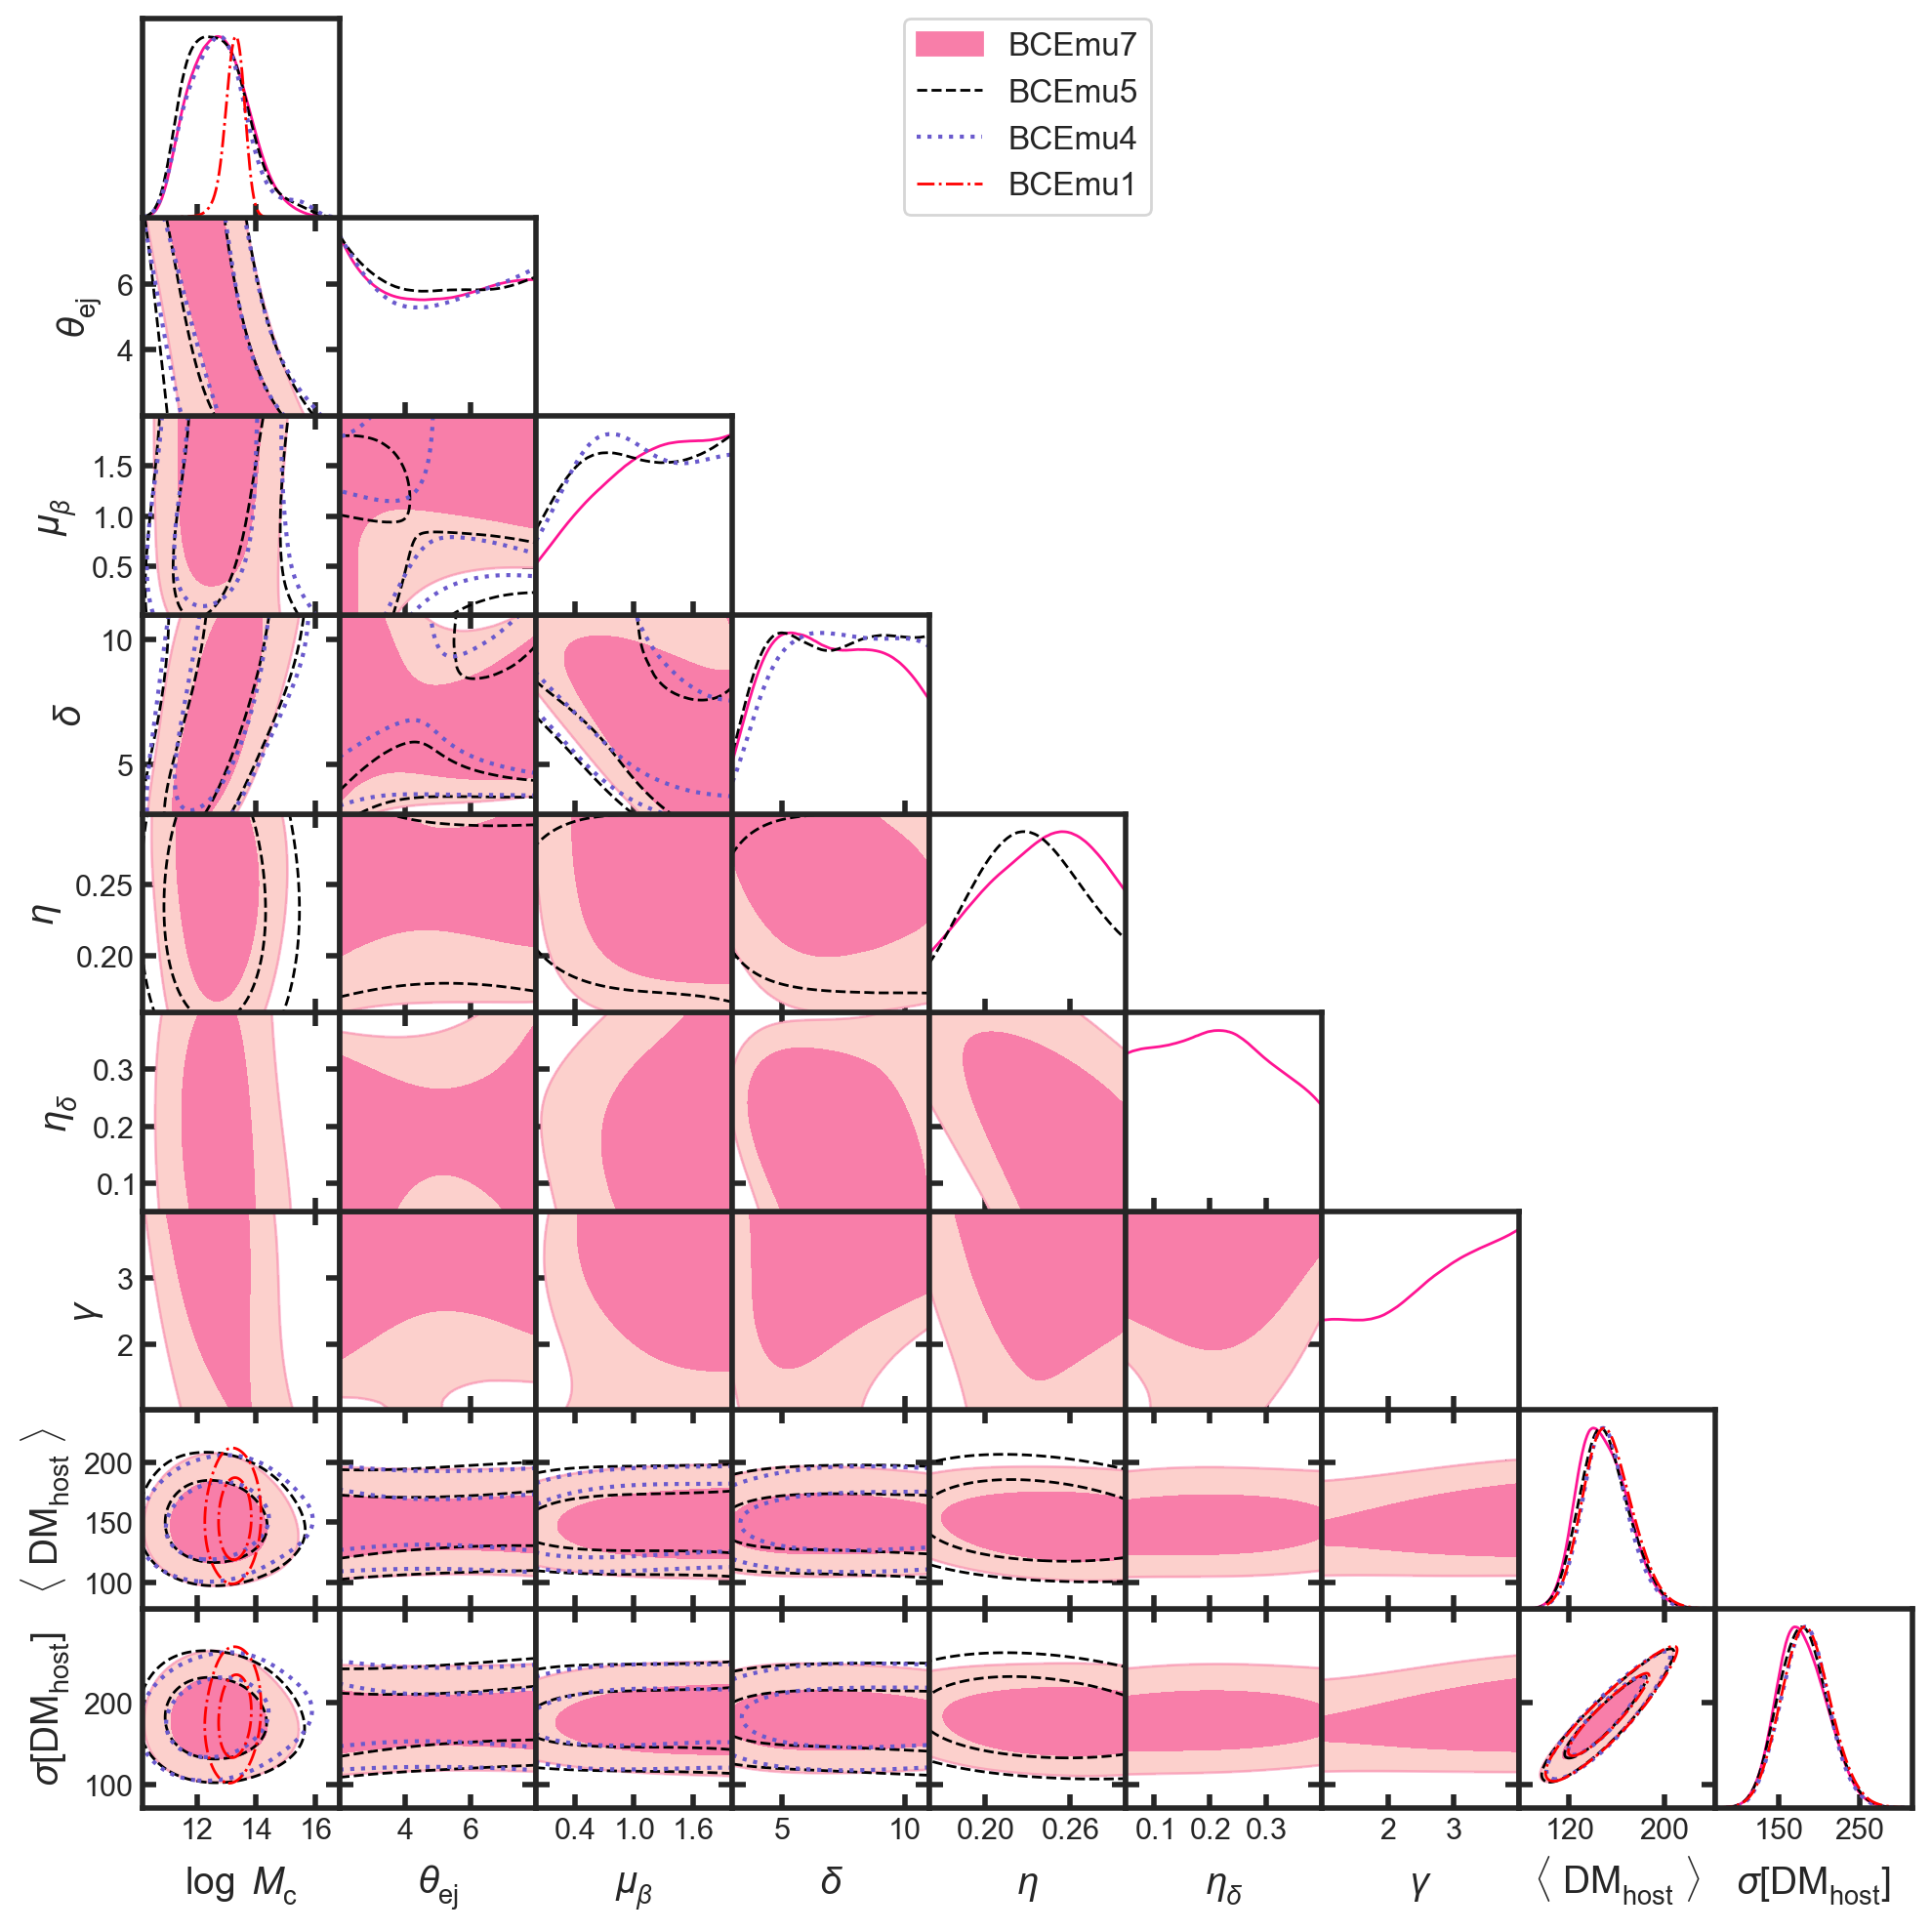

In [3]:
from getdist import MCSamples, plots

settings = {'ignore_rows':0, 'smooth_scale_1D':0.5, 'smooth_scale_2D':0.99}
samples = list((np.loadtxt("emulators/BCEmu7_high_z/param_grid_prior_example.csv", delimiter=",", skiprows=1)[:, 4:])[:, [0, 1, 3, 5, 4, 6, 2]])
new_col1 = np.random.uniform(4, 6, len(samples))[:, None]
new_col2 = np.random.uniform(0.2, 1, len(samples))[:, None]
samples = np.hstack([samples, new_col1, new_col2])

prior_chain = MCSamples(samples=samples, 
                        names=[r"\log M_{\mathrm{c}}", r"\theta_\mathrm{ej}", r"\mu_\beta", r"\delta", 
                               r"\gamma", r"\eta", r"\eta_\delta", r"\langle~\mathrm{DM}_\mathrm{host}~\rangle", r"\sigma[\mathrm{DM}_\mathrm{host}]"], 
                        labels=[r"\log M_{\mathrm{c}}", r"\theta_\mathrm{ej}", r"\mu_\beta", r"\delta", 
                                r"\gamma", r"\eta", r"\eta_\delta", r"\langle~\mathrm{DM}_\mathrm{host}~\rangle", r"\sigma[\mathrm{DM}_\mathrm{host}]"], 
                        settings=settings, label="Prior", 
                        ranges = {r"\log M_{\mathrm{c}}": [11, 16], r"\theta_\mathrm{ej}": [2, 8], r"\mu_\beta": [0.01, 2], 
                                   r"\delta": [3, 11], r"\gamma": [1, 4], r"\eta": [0.16, 0.3], r"\eta_\delta": [0.05, 0.4],
                                   r"\langle~\mathrm{DM}_\mathrm{host}~\rangle": [10, 310], r"\sigma[\mathrm{DM}_\mathrm{host}]": [10, 410]
                                  })

settings = {'ignore_rows':0, 'smooth_scale_1D':0.5, 'smooth_scale_2D':0.99}

# log_Mc, mu_beta, eta, theta_ej, eta_delta, gamma, delta
BCEmu7_chain = MCSamples(samples=BCEmu7_samples, 
                         names=[r"\log~M_{\mathrm{c}}", r"\theta_\mathrm{ej}", r"\mu_\beta", r"\delta", r"\eta", 
                                r"\eta_\delta", r"\gamma", r"\langle~\mathrm{DM}_\mathrm{host}~\rangle", r"\sigma[\mathrm{DM}_\mathrm{host}]"], 
                         labels=[r"\log~M_{\mathrm{c}}", r"\theta_\mathrm{ej}", r"\mu_\beta", r"\delta", r"\eta", 
                                r"\eta_\delta", r"\gamma", r"\langle~\mathrm{DM}_\mathrm{host}~\rangle", r"\sigma[\mathrm{DM}_\mathrm{host}]"],
                         settings=settings, label="BCEmu7", 
                         ranges = {r"\log M_{\mathrm{c}}": [11, 16], r"\theta_\mathrm{ej}": [2, 8], r"\mu_\beta": [0.01, 2], 
                                   r"\delta": [3, 11], r"\gamma": [1, 4], r"\eta": [0.16, 0.3], r"\eta_\delta": [0.05, 0.4],
                                   r"\langle~\mathrm{DM}_\mathrm{host}~\rangle": [10, 310], r"\sigma[\mathrm{DM}_\mathrm{host}]": [10, 410]
                                  })

BCEmu4_chain = MCSamples(samples=BCEmu4_samples, 
                         names=[r"\log~M_{\mathrm{c}}", r"\theta_\mathrm{ej}", r"\mu_\beta", r"\delta", 
                                r"\langle~\mathrm{DM}_\mathrm{host}~\rangle", r"\sigma[\mathrm{DM}_\mathrm{host}]"], 
                         labels=[r"\log~M_{\mathrm{c}}", r"\theta_\mathrm{ej}", r"\mu_\beta", r"\delta", 
                                 r"\langle~\mathrm{DM}_\mathrm{host}~\rangle", r"\sigma[\mathrm{DM}_\mathrm{host}]"], 
                         settings=settings, label="BCEmu4", 
                         ranges = {r"\log M_{\mathrm{c}}": [11, 16], r"\mu_\beta": [0.01, 2], r"\theta_\mathrm{ej}": [2, 8], r"\delta": [3, 11],
                                   r"\langle~\mathrm{DM}_\mathrm{host}~\rangle": [10, 310], r"\sigma[\mathrm{DM}_\mathrm{host}]": [10, 410]})

BCEmu5_chain = MCSamples(samples=BCEmu5_samples, 
                         names=[r"\log~M_{\mathrm{c}}", r"\theta_\mathrm{ej}", r"\mu_\beta", r"\delta", r"\eta", 
                                r"\langle~\mathrm{DM}_\mathrm{host}~\rangle", r"\sigma[\mathrm{DM}_\mathrm{host}]"], 
                         labels=[r"\log~M_{\mathrm{c}}", r"\theta_\mathrm{ej}", r"\mu_\beta", r"\delta", r"\eta", 
                                 r"\langle~\mathrm{DM}_\mathrm{host}~\rangle", r"\sigma[\mathrm{DM}_\mathrm{host}]"], 
                         settings=settings, label="BCEmu5", 
                         ranges = {r"\log M_{\mathrm{c}}": [11, 16], r"\mu_\beta": [0.01, 2], r"\theta_\mathrm{ej}": [2, 8], r"\delta": [3, 11], r"\eta": [0.16, 0.3],
                                   r"\langle~\mathrm{DM}_\mathrm{host}~\rangle": [10, 310], r"\sigma[\mathrm{DM}_\mathrm{host}]": [10, 410]})

BCEmu1_chain = MCSamples(samples=BCEmu1_samples, 
                         names=[r"\log~M_{\mathrm{c}}", r"\langle~\mathrm{DM}_\mathrm{host}~\rangle", r"\sigma[\mathrm{DM}_\mathrm{host}]"], 
                         labels=[r"\log M_{\mathrm{c}}", r"\langle~\mathrm{DM}_\mathrm{host}~\rangle", r"\sigma[\mathrm{DM}_\mathrm{host}]"], 
                         settings=settings, label="BCEmu1", 
                         ranges = {r"\log M_{\mathrm{c}}": [11, 16], r"\langle~\mathrm{DM}_\mathrm{host}~\rangle": [10, 310], r"\sigma[\mathrm{DM}_\mathrm{host}]": [10, 410]})

param_names = [r"\log~M_{\mathrm{c}}", r"\theta_\mathrm{ej}", r"\mu_\beta", r"\delta", r"\eta", r"\eta_\delta", 
               r"\gamma", r"\langle~\mathrm{DM}_\mathrm{host}~\rangle", r"\sigma[\mathrm{DM}_\mathrm{host}]"]
g = plots.get_subplot_plotter(subplot_size=1.15, scaling=False, rc_sizes=500)
g.triangle_plot([BCEmu7_chain, BCEmu5_chain, BCEmu4_chain, BCEmu1_chain],
                params=param_names, 
                filled=[True, False, False, False],
                contour_colors = [[plt.get_cmap("RdPu")(0.2), plt.get_cmap("RdPu")(0.45)], "black", "slateblue", "red"],
                line_args = [{"lw": 1, "color": "deeppink"}, 
                             {"lw": 1, "color": "black"}, 
                             {"lw": 1, "color": "slateblue"}, 
                             {"lw": 1, "color": "red"}],
                contour_ls = ["solid", "dashed", "dotted", "dashdot"], 
                contour_lws = [1, 1, 1.5, 1]
               )
plt.savefig('figures/BCEmu_cornerplot_getdist.pdf', dpi=400, bbox_inches='tight')


In [4]:
frb_sample = pd.read_csv("data/frb_results/frb_sample.csv")
frb_sample = frb_sample.sort_values("z_sample")

np.median(frb_sample.tail(54)["z_sample"]), np.median(frb_sample.head(54)["z_sample"])

(np.float64(0.37070000000000003), np.float64(0.07555))

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


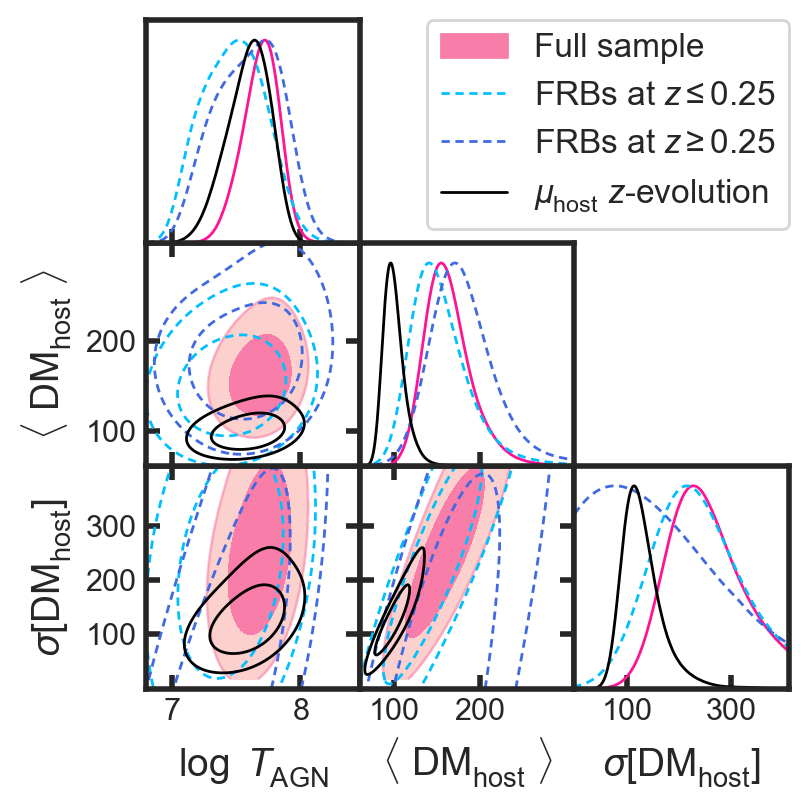

In [5]:
from getdist import MCSamples, plots

settings = {'ignore_rows':0, 'smooth_scale_1D':0.5, 'smooth_scale_2D':0.99}
new_col0 = np.random.uniform(7, 8.4, 10000)[:, None]
new_col1 = np.random.uniform(4, 6, 10000)[:, None]
new_col2 = np.random.uniform(0.2, 1, 10000)[:, None]
samples = np.hstack([new_col0, new_col1, new_col2])

prior_chain = MCSamples(samples=samples, 
                        names=[r"\log T_{\mathrm{AGN}}", r"\langle~\mathrm{DM}_\mathrm{host}~\rangle", r"\sigma[\mathrm{DM}_\mathrm{host}]"], 
                        labels=[r"\log T_{\mathrm{AGN}}", r"\langle~\mathrm{DM}_\mathrm{host}~\rangle", r"\sigma[\mathrm{DM}_\mathrm{host}]"], 
                        settings=settings, label="Prior", 
                        ranges = {r"\log T_{\mathrm{AGN}}": [7, 8.4], 
                                  r"\langle~\mathrm{DM}_\mathrm{host}~\rangle": [0, 310], 
                                  r"\sigma[\mathrm{DM}_\mathrm{host}]": [0, 410]
                                  })

HMcode_samples0 = get_samples("data/frb_results/split_two_zbins/emcee_HMcode_extended_subset_near.pkl")
HMcode_samples1 = get_samples("data/frb_results/split_two_zbins/emcee_HMcode_extended_subset_far.pkl")
HMcode_samples2 = get_samples("data/frb_results/emcee_HMcode_extended.pkl")
HMcode_samples3 = get_samples("data/frb_results/emcee_HMcode_extended_MDevolution.pkl")

settings = {'ignore_rows':0, 'smooth_scale_1D':0.5, 'smooth_scale_2D':0.99}

HMcode_chain0 = MCSamples(samples=HMcode_samples0, 
                          names=[r"\log~T_{\mathrm{AGN}}", r"\langle~\mathrm{DM}_\mathrm{host}~\rangle", r"\sigma[\mathrm{DM}_\mathrm{host}]"], 
                          labels=[r"\log~T_{\mathrm{AGN}}", r"\langle~\mathrm{DM}_\mathrm{host}~\rangle", r"\sigma[\mathrm{DM}_\mathrm{host}]"], 
                          settings=settings, label=r"FRBs at $z \leq 0.25$", 
                          ranges = {r"\log T_{\mathrm{AGN}}": [7, 8.4], 
                                    r"\langle~\mathrm{DM}_\mathrm{host}~\rangle": [0, 310], 
                                    r"\sigma[\mathrm{DM}_\mathrm{host}]": [0, 410]
                                   })

HMcode_chain1 = MCSamples(samples=HMcode_samples1, 
                          names=[r"\log~T_{\mathrm{AGN}}", r"\langle~\mathrm{DM}_\mathrm{host}~\rangle", r"\sigma[\mathrm{DM}_\mathrm{host}]"], 
                          labels=[r"\log~T_{\mathrm{AGN}}", r"\langle~\mathrm{DM}_\mathrm{host}~\rangle", r"\sigma[\mathrm{DM}_\mathrm{host}]"], 
                          settings=settings, label=r"FRBs at $z \geq 0.25$", 
                          ranges = {r"\log T_{\mathrm{AGN}}": [7, 8.4], 
                                    r"\langle~\mathrm{DM}_\mathrm{host}~\rangle": [0, 310], 
                                    r"\sigma[\mathrm{DM}_\mathrm{host}]": [0, 410]
                                   })

HMcode_chain2 = MCSamples(samples=HMcode_samples2, 
                          names=[r"\log~T_{\mathrm{AGN}}", r"\langle~\mathrm{DM}_\mathrm{host}~\rangle", r"\sigma[\mathrm{DM}_\mathrm{host}]"], 
                          labels=[r"\log~T_{\mathrm{AGN}}", r"\langle~\mathrm{DM}_\mathrm{host}~\rangle", r"\sigma[\mathrm{DM}_\mathrm{host}]"], 
                          settings=settings, label="Full sample", 
                          ranges = {r"\log T_{\mathrm{AGN}}": [7, 8.4], 
                                    r"\langle~\mathrm{DM}_\mathrm{host}~\rangle": [0, 310], 
                                    r"\sigma[\mathrm{DM}_\mathrm{host}]": [0, 410]
                                   })

HMcode_chain3 = MCSamples(samples=HMcode_samples3, 
                          names=[r"\log~T_{\mathrm{AGN}}", r"\langle~\mathrm{DM}_\mathrm{host}~\rangle", r"\sigma[\mathrm{DM}_\mathrm{host}]"], 
                          labels=[r"\log~T_{\mathrm{AGN}}", r"\langle~\mathrm{DM}_\mathrm{host}~\rangle", r"\sigma[\mathrm{DM}_\mathrm{host}]"], 
                          settings=settings, label=r"$\mu_\mathrm{host}~z$-evolution", 
                          ranges = {r"\log T_{\mathrm{AGN}}": [7, 8.4], 
                                    r"\langle~\mathrm{DM}_\mathrm{host}~\rangle": [0, 310], 
                                    r"\sigma[\mathrm{DM}_\mathrm{host}]": [0, 410]
                                   })

param_names = [r"\log~T_{\mathrm{AGN}}", r"\langle~\mathrm{DM}_\mathrm{host}~\rangle", r"\sigma[\mathrm{DM}_\mathrm{host}]"]
g = plots.get_subplot_plotter(subplot_size=1.5, scaling=False, rc_sizes=500)
g.triangle_plot([HMcode_chain2, HMcode_chain0, HMcode_chain1, HMcode_chain3], 
                params=param_names, 
                filled=[True, False, False, False],
                contour_colors = [[plt.get_cmap("RdPu")(0.2), plt.get_cmap("RdPu")(0.45)], "deepskyblue", "royalblue", "black"],
                line_args = [{"lw": 1, "color": "deeppink"}, 
                             {"lw": 1, "color": "deepskyblue", "ls":"--"}, 
                             {"lw": 1, "color": "royalblue", "ls":"--"}, 
                             {"lw": 1, "color": "black"}],
                contour_ls = ["solid", "--", "--", "solid"], 
                contour_lws = [1, 1, 1, 1]
               )

plt.savefig('figures/HMcode_cornerplot_getdist.pdf', dpi=400, bbox_inches='tight')


## SP(k) constraints

Citations to related works:  <KeysViewHDF5 ['Anbajagane+(2025)', 'Aricò+(2022)', 'Bigwood+(2024)', 'Chen+(2022)', 'Dalal+(2025)', 'Kovač+(2025)', 'Pandey+(2025)', 'Terasawa+(2024)', 'Wright+(2025)', 'Xu+(2025)_6x2pt', 'Xu+(2025)_6x2ptP1P2']>


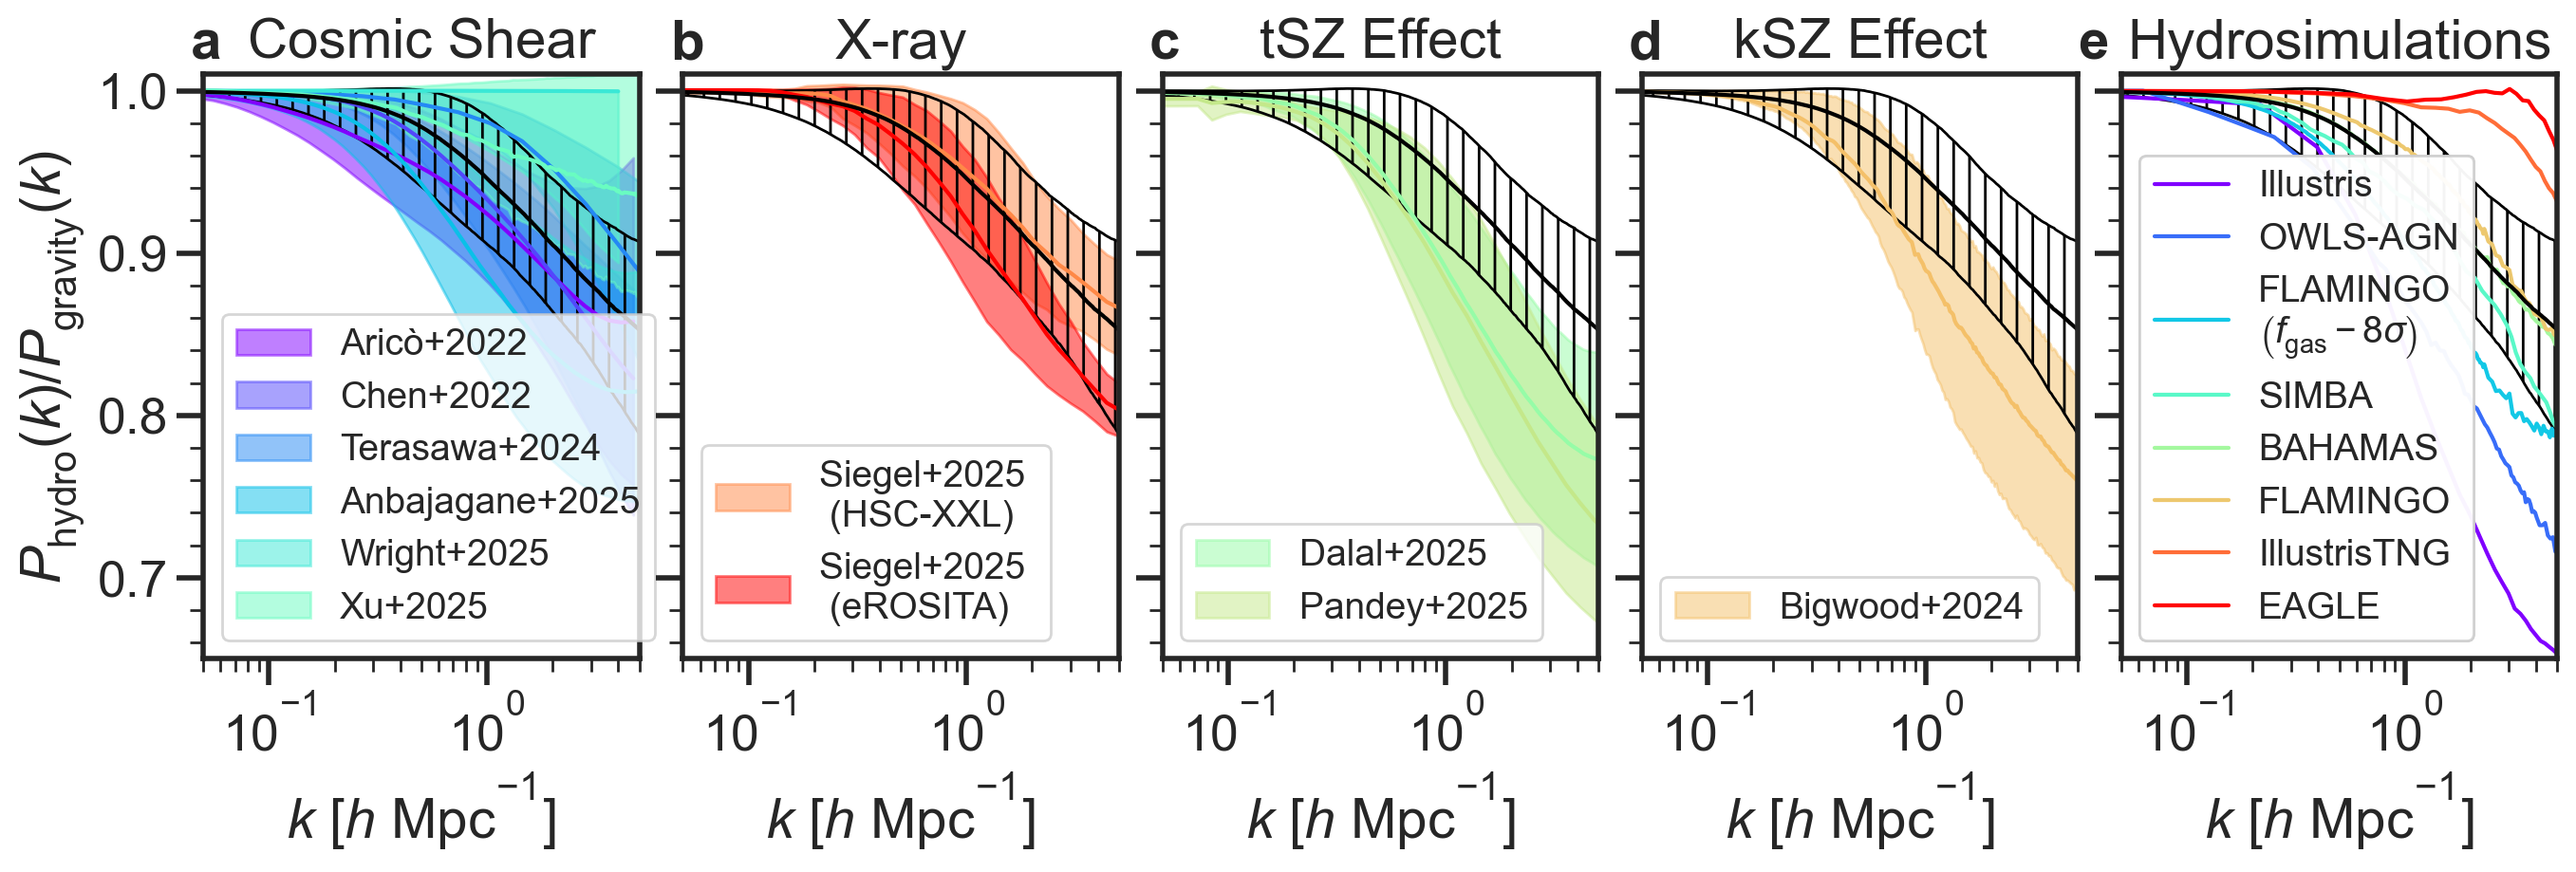

In [6]:
mpl.rcParams['axes.linewidth'] = 2
mpl.rcParams['xtick.major.width'] = 2
mpl.rcParams['ytick.major.width'] = 2
mpl.rcParams['xtick.minor.width'] = 1
mpl.rcParams['ytick.minor.width'] = 1

mpl.rcParams['xtick.major.size'] = 10
mpl.rcParams['ytick.major.size'] = 10
mpl.rcParams['xtick.minor.size'] = 5
mpl.rcParams['ytick.minor.size'] = 5


cmap = plt.get_cmap("rainbow")
colors = [cmap(i) for i in np.linspace(0, 1, 12)]

fig, (ax0, ax4, ax1, ax2, ax3) = plt.subplots(1, 5, figsize=(16, 4), sharey=True)
plt.subplots_adjust(wspace=0.1)
out_fname = "data/literature_constraints/combined_Sk_k_z0.hdf5"
with h5py.File(out_fname, "r") as f:
    print("Citations to related works: ", f.keys())
    
    example_data = f["Aricò+(2022)"]
    ax0.semilogx(example_data["k"][()], example_data["Sk_mean"][()], color=colors[0])
    ax0.fill_between(example_data["k"][()], example_data["Sk_low"][()], example_data["Sk_high"][()], alpha=0.5, color=colors[0], label="Aricò+2022")
    
    example_data = f["Chen+(2022)"]
    ax0.semilogx(example_data["k"][()], example_data["Sk_mean"][()], color=colors[1])
    ax0.fill_between(example_data["k"][()], example_data["Sk_low"][()], example_data["Sk_high"][()], alpha=0.5, color=colors[1], label="Chen+2022")
    
    example_data = f["Terasawa+(2024)"]
    ax0.semilogx(example_data["k"][()], example_data["Sk_mean"][()], color=colors[2])
    ax0.fill_between(example_data["k"][()], example_data["Sk_low"][()], example_data["Sk_high"][()], alpha=0.5, color=colors[2], label="Terasawa+2024")
    
    example_data = f["Anbajagane+(2025)"]
    ax0.semilogx(example_data["k"][()], example_data["Sk_mean"][()], color=colors[3])
    ax0.fill_between(example_data["k"][()], example_data["Sk_low"][()], example_data["Sk_high"][()], alpha=0.5, color=colors[3], label="Anbajagane+2025")
    
    example_data = f["Wright+(2025)"]
    ax0.semilogx(example_data["k"][()], example_data["Sk_mean"][()], color=colors[4])
    ax0.fill_between(example_data["k"][()], example_data["Sk_low"][()], example_data["Sk_high"][()], alpha=0.5, color=colors[4], label="Wright+2025")
    
    example_data = f["Xu+(2025)_6x2pt"]
    ax0.semilogx(example_data["k"][()], example_data["Sk_mean"][()], color=colors[5])
    ax0.fill_between(example_data["k"][()], example_data["Sk_low"][()], example_data["Sk_high"][()], alpha=0.5, color=colors[5], label="Xu+2025")
    
    
    ax0.set(xlim = [5e-2, 5], ylim=[0.65, 1.05], xlabel=r'$k$ $[h~\mathrm{Mpc}^{-1}]$',
            ylabel=r'$P_\mathrm{hydro}(k)/P_\mathrm{gravity}(k)$')
    ax0.legend(fontsize=14, ncol=1, loc="lower left")
 
    example_data = f["Dalal+(2025)"]
    ax1.semilogx(example_data["k"][()], example_data["Sk_mean"][()], color=colors[6])
    ax1.fill_between(example_data["k"][()], example_data["Sk_low"][()], example_data["Sk_high"][()], alpha=0.5, color=colors[6], label="Dalal+2025")
    
    example_data = f["Pandey+(2025)"]
    ax1.semilogx(example_data["k"][()], example_data["Sk_mean"][()], color=colors[7])
    ax1.fill_between(example_data["k"][()], example_data["Sk_low"][()], example_data["Sk_high"][()], alpha=0.5, color=colors[7], label="Pandey+2025")
    
    
    ax1.set(xlim = [5e-2, 5], xlabel=r'$k$ $[h~\mathrm{Mpc}^{-1}]$')
    ax1.legend(fontsize=14, loc="lower left")
    
    example_data = f["Bigwood+(2024)"]
    ax2.semilogx(example_data["k"][()], example_data["Sk_mean"][()], color=colors[8])
    ax2.fill_between(example_data["k"][()], example_data["Sk_low"][()], example_data["Sk_high"][()], alpha=0.5, color=colors[8], label="Bigwood+2024")
        
    k_low, spk_low = pd.read_csv("data/literature_constraints/Siegel_preEROSITA_fgas_low.csv").x, pd.read_csv("data/literature_constraints/Siegel_preEROSITA_fgas_low.csv").y
    k_high, spk_high = pd.read_csv("data/literature_constraints/Siegel_preEROSITA_fgas_high.csv").x, pd.read_csv("data/literature_constraints/Siegel_preEROSITA_fgas_high.csv").y
    k_common = 10**np.linspace(-2, np.log10(5))
    spk_low = np.interp(k_common, k_low, spk_low)
    spk_high = np.interp(k_common, k_high, spk_high)
    ax4.semilogx(k_common, (spk_low+spk_high)/2, color=colors[9])
    ax4.fill_between(k_common, spk_low, spk_high, alpha=0.5, color=colors[9], label="Siegel+2025 \n (HSC-XXL)")
    
    k_low, spk_low = pd.read_csv("data/literature_constraints/Siegel_EROSITA_fgas_low.csv").x, pd.read_csv("data/literature_constraints/Siegel_EROSITA_fgas_low.csv").y
    k_high, spk_high = pd.read_csv("data/literature_constraints/Siegel_EROSITA_fgas_high.csv").x, pd.read_csv("data/literature_constraints/Siegel_EROSITA_fgas_high.csv").y
    k_common = 10**np.linspace(-2, np.log10(5))
    spk_low = np.interp(k_common, k_low, spk_low)
    spk_high = np.interp(k_common, k_high, spk_high)
    ax4.semilogx(k_common, (spk_low+spk_high)/2, color=colors[11])
    ax4.fill_between(k_common, spk_low, spk_high, alpha=0.5, color=colors[11], label="Siegel+2025 \n (eROSITA)")
    
    ax4.set(xlim = [5e-2, 5], xlabel=r'$k$ $[h~\mathrm{Mpc}^{-1}]$')
    ax4.legend(fontsize=14, loc="lower left")
        
    ax2.set(xlim = [5e-2, 5], xlabel=r'$k$ $[h~\mathrm{Mpc}^{-1}]$')
    ax2.legend(fontsize=14, loc="lower left")


from astropy.cosmology import Planck18 as cosmo
k_fields = np.geomspace(1e-4, 1e2, 1000)
for ax in [ax0, ax1, ax2, ax4]:         
    ratio_spk_lo, ratio_spk_med, ratio_spk_hi = np.load('data/frb_results/spk_BCEmu5_extended_Chandraprior.npy')
    ax.fill_between(k_fields/(cosmo.H0.value/100), ratio_spk_lo, ratio_spk_hi, facecolor='none', edgecolor='black', hatch='||', alpha=1, label="FRBs-BCEmu3")
    ax.plot(k_fields/(cosmo.H0.value/100), ratio_spk_med, color="black")
    
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(0.02))


cmap = plt.get_cmap("rainbow")
colors = [cmap(i) for i in np.linspace(0, 1, 8)]

hydro_illustris = np.genfromtxt("data/hydrosims_spk/logPkRatio_illustris.dat")
hydro_owls_agn = np.genfromtxt("data/hydrosims_spk/logPkRatio_cowls_AGN_T85.dat")
hydro_tng = np.genfromtxt("data/hydrosims_spk/logPkRatio_TNG100.dat")
flamingo_hydro_8sigma = h5py.File("data/hydrosims_spk/fgas-8sigma.hdf5",'r')
flamingo_hydro = h5py.File("data/hydrosims_spk/L1_m9.hdf5",'r')
flamingo_dark = h5py.File("data/hydrosims_spk/L1_m9_DMO.hdf5",'r')
df = pd.read_csv("data/hydrosims_spk/logPkRatio_BAHAMAS_T78.dat", delim_whitespace=True, comment='#')
k_bahamas = 10**df["logk"]; PkRatio_bahamas = 10**df["z000"]
df = pd.read_csv("data/hydrosims_spk/logPkRatio_eagle.dat", delim_whitespace=True, comment='#')
k_eagle = 10**df["logk"]; PkRatio_eagle = 10**df["z000"]

df = pd.read_csv("data/hydrosims_spk/logPkRatio_simba.csv")
k_simba = df["k"]; PkRatio_simba = df["SPk"]

lw=1.5
ax3.plot(10**hydro_illustris[:,0], 10**hydro_illustris[:,-1], label="Illustris", lw=lw, color=colors[0])
ax3.plot(10**hydro_owls_agn[:,0], 10**hydro_owls_agn[:,-1], label="OWLS-AGN", lw=lw, color=colors[1])
ax3.plot(flamingo_dark['z=0.00']['k'][:], flamingo_hydro_8sigma['z=0.00']['P(k)'][:]/flamingo_dark['z=0.00']['P(k)'][:], label="FLAMINGO\n$\\left(f_\\mathrm{gas}-8\\sigma\\right)$", lw=lw, color=colors[2])
ax3.plot(k_simba, PkRatio_simba, label="SIMBA", lw=lw, color=colors[3])
ax3.plot(k_bahamas, PkRatio_bahamas, label="BAHAMAS", lw=lw, color=colors[4])
ax3.plot(flamingo_dark['z=0.00']['k'][:], flamingo_hydro['z=0.00']['P(k)'][:]/flamingo_dark['z=0.00']['P(k)'][:], label="FLAMINGO", lw=lw, color=colors[5])
ax3.plot(10**hydro_tng[:,0], 10**hydro_tng[:,-1], label="IllustrisTNG", lw=lw, color=colors[6])
ax3.plot(k_eagle, PkRatio_eagle, label="EAGLE", lw=lw, color=colors[7])

ax3.set_xlim(0.05, 5); ax3.set_xscale('log'); ax3.set_xlabel(r'$k$ $[h~\mathrm{Mpc}^{-1}]$')
ax3.set_ylim(0.65, 1.01)

legend1=ax3.legend(fontsize=14)
ax3.add_artist(legend1)

ratio_spk_lo, ratio_spk_med, ratio_spk_hi = np.load('data/frb_results/spk_BCEmu5_extended_Chandraprior.npy')
ax3.fill_between(k_fields/(cosmo.H0.value/100), ratio_spk_lo, ratio_spk_hi, facecolor='none', edgecolor='black', hatch='||', alpha=1, label="BCEmu4")
ax3.plot(k_fields/(cosmo.H0.value/100), ratio_spk_med, color="black")

ax3.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax3.yaxis.set_minor_locator(plt.MultipleLocator(0.02))

ax0.text(-0.03, 1.05, "a", ha='left', va='center', weight='bold', transform=ax0.transAxes)
ax1.text(-0.03, 1.05, "c", ha='left', va='center', weight='bold', transform=ax1.transAxes)
ax2.text(-0.03, 1.05, "d", ha='left', va='center', weight='bold', transform=ax2.transAxes)
ax4.text(-0.03, 1.05, "b", ha='left', va='center', weight='bold', transform=ax4.transAxes)
ax3.text(-0.1, 1.05, "e", ha='left', va='center', weight='bold', transform=ax3.transAxes)
ax0.set_title("Cosmic Shear"); ax1.set_title("tSZ Effect"); ax2.set_title("kSZ Effect"); ax4.set_title("X-ray"); ax3.set_title("Hydrosimulations")

plt.savefig('figures/spk_constraints.pdf', dpi=400, bbox_inches='tight')



In [7]:
idx = np.argmin(np.abs((k_fields/(cosmo.H0.value/100))-1))
posterior_samples = np.load('data/frb_results/spk_BCEmu5_posterior_samples_feedbackonly_extended_Chandraprior.npy')[:, idx]

with h5py.File(out_fname, "r") as f:
    example_data = f["Bigwood+(2024)"]      
    x_ref1 = np.interp(1, example_data["k"][()], example_data["Sk_low"][()])
    x_ref2 = np.interp(1, example_data["k"][()], example_data["Sk_mean"][()])
    x_ref3 = np.interp(1, example_data["k"][()], example_data["Sk_high"][()])
    
mu1 = np.mean(posterior_samples)
sigma1 = np.std(posterior_samples)
mu2  = x_ref2
sigma2 = (x_ref3 - x_ref1)/2
tension_sigma = (mu1 - mu2) / np.sqrt(sigma1**2 + sigma2**2)

print("Tension (sigma units):", round(tension_sigma, 2))


Tension (sigma units): 0.83


In [8]:
idx = np.argmin(np.abs((k_fields/(cosmo.H0.value/100))-1))
posterior_samples = np.load('data/frb_results/spk_BCEmu5_posterior_samples_feedbackonly_extended_Chandraprior.npy')[:, idx]

x_ref1 = np.interp(1, k_eagle, PkRatio_eagle)

mu1 = np.mean(posterior_samples)
sigma1 = np.std(posterior_samples)
mu2  = x_ref1
tension_sigma = (mu1 - mu2) / sigma1

print("Tension (sigma units):", round(tension_sigma, 2))


Tension (sigma units): -1.23


# f_diffuse/f_gas


In [9]:
os.environ["PK_MODEL"] = "BCEmu7_high_z"
os.environ["METHOD"] = "exact"
os.environ["N_FRB"]    = "100"
os.environ["N_PARAMS"] = "1"
os.environ["DIR_PATH"] = "data/frb_results"
os.environ["SAMPLE"] = "frb_sample"
os.environ["SAMPLE_EXTENDED"] = "Yes"
from mcmc_funcs import *
from astropy.cosmology import Planck18 as cosmo

f_diffuse = f_diffuse(np.array([cosmo.H0.cgs.value for i in range(100)]), 
                      np.array([cosmo.Ob0 for i in range(100)]), 
                      np.array([cosmo.Om0 for i in range(100)]), 
                      np.array([0.8111 for i in range(100)]), 
                      np.array([
                          {"log_Mc": BCEmu5_samples[i, 0], "theta_ej": BCEmu5_samples[i, 1], 
                           "eta_delta": 0.2, "delta": BCEmu5_samples[i, 3], 
                           "mu_beta": BCEmu5_samples[i, 2], "gamma": 2.5, 
                           "eta": BCEmu5_samples[i, 4], "A": 0.055/2, "tau": -1.5
                          } for i in range(100)]), 
                      "BCEmu5", np.array([0]))
round(np.percentile(f_diffuse, 50), 4), round(np.percentile(f_diffuse, 16)-np.percentile(f_diffuse, 50), 4), round(np.percentile(f_diffuse, 84)-np.percentile(f_diffuse, 50), 4)


Not using emulators.
Unknown Pk_model!


(0.9031, -0.0151, 0.0142)

In [10]:
class HMCalculator_NoCorrection(ccl.halos.halo_model.HMCalculator):
    def _integrate_over_mf(self, array_2): #  ∫ dM n(M) f(M)
        i1 = self._integrator(self._mf * array_2, self._lmass)
        return i1 #+ self._mf0 * array_2[..., 0]

    def _integrate_over_mbf(self, array_2): # ∫ dM n(M) b(M) f(M)
        i1 = self._integrator(self._mf * self._bf * array_2, self._lmass)
        return i1 #+ self._mbf0 * array_2[..., 0]
    
def get_fgas(H0_arr, Ob0_arr, Om0_arr, s8_arr, feedback_params_list, Pk_model, z, log_Mmin, log_Mmax, mode = HMcode_mode):
    def get_Mgas_element(H0, Ob0, Om0, s8, feedback_params, Pk_model, z, HMcode_mode):
        a = 1/(1+z)
        h = H0/(100*1e5/Mpc)
        cosmo = ccl.Cosmology(Omega_c = Om0-Ob0, Omega_b = Ob0, h = H0/(100*1e5/Mpc), 
                              sigma8 = s8, n_s = 0.9665, matter_power_spectrum='linear')
        def gas_dm_profile_integral(M, a):
            if Pk_model == "HMcode":
                par = bfg.Profiles.Mead20.Tagn2pars(feedback_params["Tagn"], mode = mode)
                GAS_temp = bfg.Profiles.Mead20.Gas(**par)
                STR_temp = bfg.Profiles.Mead20.Stars(**par)
            elif "BCEmu" in Pk_model:
                par = dict(theta_ej = feedback_params["theta_ej"], theta_co = 0.1,
                        M_c = (10**feedback_params["log_Mc"])/h,
                        mu_beta = feedback_params["mu_beta"],
                        eta = feedback_params["eta"],
                        eta_delta = feedback_params["eta_delta"], tau = -1.5,
                        tau_delta = 0, A = feedback_params["A"], M1 = 2.5e11/h,
                        epsilon_h = 0.015, a = 0.3, n = 2, epsilon = 4, p = 0.3,
                        q = 0.707, gamma = feedback_params["gamma"],
                        delta = feedback_params["delta"])
                GAS_temp = bfg.Profiles.Schneider19.Gas(**par)
                STR_temp = bfg.Profiles.Schneider19.Stars(**par)
            else:
                print("Unknown Pk model!")
            output_GAS, output_STR = [], []
            for elem in range(len(M)):
                R200c = ccl.halos.massdef.MassDef200c.get_radius(cosmo, M[elem], a)/a
                R = np.geomspace(1e-5 * R200c, R200c, 1000)
                GAS = GAS_temp.real(cosmo, M=M[elem], r=R, a=a)
                STR = STR_temp.real(cosmo, M=M[elem], r=R, a=a)
                output_GAS.append(scipy.integrate.simpson(GAS*4*np.pi*R**2, x=R))
                output_STR.append(scipy.integrate.simpson(STR*4*np.pi*R**2, x=R))
            return output_GAS, output_STR

        HMC  = HMCalculator_NoCorrection(mass_function = 'Tinker08', halo_bias = 'Tinker10', 
                                         mass_def = ccl.halos.massdef.MassDef200c, 
                                         log10M_min = log_Mmin, log10M_max = log_Mmax, nM = 1000)
        HMC_total  = ccl.halos.halo_model.HMCalculator(mass_function = 'Tinker08', halo_bias = 'Tinker10', 
                                         mass_def = ccl.halos.massdef.MassDef200c, 
                                         log10M_min = 9, log10M_max = 16, nM = 1000)
        fgas = []; fstar = []
        for this_a in np.atleast_1d(a):
            int_gas = lambda M: gas_dm_profile_integral(M, this_a)[0]
            int_star = lambda M: gas_dm_profile_integral(M, this_a)[1]
            
            fgas.append(HMC.integrate_over_massfunc(int_gas, cosmo, this_a)/HMC_total.integrate_over_massfunc(lambda M: M, cosmo, this_a))
            fstar.append(HMC.integrate_over_massfunc(int_star, cosmo, this_a)/HMC_total.integrate_over_massfunc(lambda M: M, cosmo, this_a))
        
        return np.array(fgas), np.array(fstar)

    def run_one(idx):
        H0, Ob0, Om0, s8, feedback_params = H0_arr[idx], Ob0_arr[idx], Om0_arr[idx], s8_arr[idx], feedback_params_list[idx]
        return get_Mgas_element(H0, Ob0, Om0, s8, feedback_params, Pk_model, z, HMcode_mode)

    output = Parallel(n_jobs=5)(delayed(run_one)(i) for i in tqdm(range(len(H0_arr))))
    fgas, fstar = np.array(output)[:, 0], np.array(output)[:, 1]
    return fgas, fstar


log_Mmins, log_Mmaxs = [9, np.log10(10**12.7), 14, 9, 10], [np.log10(10**12.7), 14, 16, 16, 14]
for i in range(len(log_Mmins)):
    f_gas, f_star = get_fgas(
        np.array([cosmo.H0.cgs.value for i in range(100)]), 
        np.array([cosmo.Ob0 for i in range(100)]), 
        np.array([cosmo.Om0 for i in range(100)]), 
        np.array([0.8111 for i in range(100)]), 
        np.array([
            {
                "log_Mc": BCEmu5_samples[i, 0], "theta_ej": BCEmu5_samples[i, 1], 
                "eta_delta": 0.2, "delta": BCEmu5_samples[i, 3], 
                "mu_beta": BCEmu5_samples[i, 2], "gamma": 2.5, 
                "eta": BCEmu5_samples[i, 4], "A": 0.055/2, "tau": -1.5
            } for i in range(100)]),
        "BCEmu5",
        np.array([0]),
        log_Mmins[i], log_Mmaxs[i]
    )
    print(round(log_Mmins[i], 2), round(log_Mmaxs[i], 2))
    print(round(np.percentile(f_gas/(cosmo.Ob0/cosmo.Om0), 50), 4), 
          round(np.percentile(f_gas/(cosmo.Ob0/cosmo.Om0), 16)-np.percentile(f_gas/(cosmo.Ob0/cosmo.Om0), 50), 4), 
          round(np.percentile(f_gas/(cosmo.Ob0/cosmo.Om0), 84)-np.percentile(f_gas/(cosmo.Ob0/cosmo.Om0), 50), 4))
    print(round(np.percentile((f_gas+f_star)/(cosmo.Ob0/cosmo.Om0), 50), 4), 
          round(np.percentile((f_gas+f_star)/(cosmo.Ob0/cosmo.Om0), 16)-np.percentile((f_gas+f_star)/(cosmo.Ob0/cosmo.Om0), 50), 4), 
          round(np.percentile((f_gas+f_star)/(cosmo.Ob0/cosmo.Om0), 84)-np.percentile((f_gas+f_star)/(cosmo.Ob0/cosmo.Om0), 50), 4))




100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:56<00:00,  1.76it/s]


9 12.7
0.0174 -0.0135 0.0312
0.0568 -0.0127 0.0302


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [01:12<00:00,  1.37it/s]


12.7 14
0.0554 -0.0331 0.0139
0.0689 -0.0305 0.0129


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [01:15<00:00,  1.33it/s]


14 16
0.0379 -0.0078 0.0057
0.0399 -0.0085 0.0052


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:54<00:00,  1.82it/s]


9 16
0.1077 -0.0323 0.0378
0.1659 -0.0396 0.0363


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:51<00:00,  1.93it/s]


10 14
0.0726 -0.0366 0.0288
0.1234 -0.0383 0.0345


## f_gas(Mhalo) and rho_gas(R)

In [9]:
cosmo_ccl = ccl.Cosmology(Omega_c = cosmo.Om0-cosmo.Ob0, 
                      Omega_b = cosmo.Ob0, 
                      h = cosmo.H0.value/100, 
                      sigma8 = 0.8111, 
                      n_s = 0.9665, 
                      matter_power_spectrum='linear'
                     )
fb = cosmo_ccl.cosmo.params.Omega_b / cosmo_ccl.cosmo.params.Omega_m # Cosmic baryon fraction

def compute_mass_fraction(Profile, Mass, a = 1, Rfac = 1):
    mdef  = ccl.halos.massdef.MassDef500c
    R500c = mdef.get_radius(cosmo_ccl, Mass, a) / a
    out   = np.zeros_like(Mass) + -99
    for i in range(Mass.size):        
        r = np.geomspace(R500c[i] * 1e-8, R500c[i] * Rfac, 1000)
        m = np.trapz(4 * np.pi * r**2 * Profile.real(cosmo_ccl, r, Mass[i], a), x = r) #Cumulative mass fraction
        out[i] = m/Mass[i] 
    return out

c_M_relation = ccl.halos.concentration.ConcentrationIshiyama21


In [10]:
M500c = np.geomspace(1e12, 1e15, 50)

fgas_BCEmu5, fstr_BCEmu5 = [], []
for i in tqdm(range(1000)):
    par = dict(theta_ej = BCEmu5_samples[i, 1], theta_co = 0.1, M_c = (10**BCEmu5_samples[i, 0])/cosmo_ccl.cosmo.params.h, 
               mu_beta = BCEmu5_samples[i, 2], eta = BCEmu5_samples[i, 4], eta_delta = 0.2, tau = -1.5, tau_delta = 0, A = 0.055/2, 
               M1 = 2.5e11/cosmo_ccl.cosmo.params.h, epsilon_h = 0.015, a = 0.3, n = 2, 
               epsilon = 4, p = 0.3, q = 0.707, gamma = 2.5, delta = BCEmu5_samples[i, 3])
    GAS = bfg.Profiles.Schneider19.Gas(**par, mass_def = ccl.halos.massdef.MassDef500c, c_M_relation=c_M_relation)
    STR = bfg.Profiles.Schneider19.Stars(**par, mass_def = ccl.halos.massdef.MassDef500c, c_M_relation=c_M_relation)
    fgas_BCEmu5.append(compute_mass_fraction(GAS, M500c))
    fstr_BCEmu5.append(compute_mass_fraction(STR, M500c))
fbaryon_BCEmu5 = np.array(fgas_BCEmu5) + np.array(fstr_BCEmu5)



100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:44<00:00, 22.71it/s]


In [11]:
data = np.loadtxt("data/literature_constraints/Popesso_gasfrac_mean.csv", delimiter=",")
Popesso_mass = 10**data[:, 0]
Popesso_mean = data[:, 1]*fb

data = np.loadtxt("data/literature_constraints/Popesso_gasfrac_err.csv", delimiter=",")
popesso_erru = (data[:, 1])*fb-Popesso_mean


data = np.loadtxt("data/literature_constraints/Akino_pre-Erosita_gasfrac_high.csv", delimiter=",")
akino_mass_temp = data[:, 0]
akino_temp = data[:, 1]
akino_gasfrac_high = np.interp(np.log10(M500c), akino_mass_temp, akino_temp)

data = np.loadtxt("data/literature_constraints/Akino_pre-Erosita_gasfrac_low.csv", delimiter=",")
akino_mass_temp = data[:, 0]
akino_temp = data[:, 1]
akino_gasfrac_low = np.interp(np.log10(M500c), akino_mass_temp, akino_temp)


jared_data = {'z0m0': {'m500': 51371184229872.375,
  'm500_err': 11592373974144.781,
  'm200': 78388665273215.89,
  'mgas': 2096840162843.292,
  'mgas_err': 59030681466.28824,
  'Z': 0.0763},
 'z0m1': {'m500': 154259183021685.1,
  'm500_err': 18878801258874.6,
  'm200': 237507639810426.53,
  'mgas': 9716245602557.29,
  'mgas_err': 146305849142.62698,
  'Z': 0.0799},
 'z1m0': {'m500': 69921625144438.27,
  'm500_err': 11165100631499.465,
  'm200': 107981572158676.08,
  'mgas': 2819070858845.839,
  'mgas_err': 94791740875.92151,
  'Z': 0.14745},
 'z1m1': {'m500': 156011410846166.47,
  'm500_err': 13211743875459.688,
  'm200': 237868441064638.78,
  'mgas': 10259708816629.223,
  'mgas_err': 125322258829.75293,
  'Z': 0.1544}}
jared_mass = [jared_data[key]['m500'] for key in jared_data.keys()]
jared_fgas = np.array([jared_data[key]['mgas']/jared_data[key]['m500'] for key in jared_data.keys()])
jared_fgas_err = jared_fgas*np.array([(jared_data[key]['mgas_err']/jared_data[key]['mgas']) for key in jared_data.keys()])


In [12]:
mdef  = ccl.halos.massdef.MassDef200c
gas_profiles = {}

R200c = mdef.get_radius(cosmo_ccl, 1e14, 1)
R = np.geomspace(0.1, 10, 1000)
x = R/R200c

# log_Mc, theta_ej, mu_beta, delta, eta
gas_profile = []
for i in tqdm(range(1000)):
    par = dict(theta_ej = BCEmu5_samples[i, 1], theta_co = 0.1, M_c = (10**BCEmu5_samples[i, 0])/cosmo_ccl.cosmo.params.h, 
               mu_beta = BCEmu5_samples[i, 2], eta = BCEmu5_samples[i, 4], eta_delta = 0.2, tau = -1.5, tau_delta = 0, A = 0.055/2, 
               M1 = 2.5e11/cosmo_ccl.cosmo.params.h, epsilon_h = 0.015, a = 0.3, n = 2, 
               epsilon = 4, p = 0.3, q = 0.707, gamma = 2.5, delta = BCEmu5_samples[i, 3])
    GAS = bfg.Profiles.Schneider19.Gas(**par, mass_def = mdef, c_M_relation=c_M_relation)
    gas_profile.append(x**2 * (GAS.real(cosmo_ccl, R, np.array([1e14]), 1)))
    
gas_profiles["FRBs_1e14"] = np.array(gas_profile)


param_ranges = {
    "logMc": (13.22-0.29, 13.22+0.42),
    "theta_ej": (5.15-1.48, 5.15+1.46),
    "eta_delta": (0.22-0.11, 0.22+0.1),
    "mu_beta": (0.68-0.58, 0.68+0.25), 
    "gamma": (2.66-0.67, 2.66+0.98), 
    "delta": (7.35-2.1, 7.35+2.16), 
    "eta": (0.21-0.13, 0.21+0.08)
}

n_samples = 1000
n_dim = len(param_ranges)

l_bounds = np.array([v[0] for v in param_ranges.values()])
u_bounds = np.array([v[1] for v in param_ranges.values()])
mu = (u_bounds + l_bounds) / 2
sigma = (u_bounds - l_bounds) / 2
param_grid_gauss = np.random.normal(loc=mu, scale=sigma, size=(n_samples, n_dim))
param_grid_leah = np.array(param_grid_gauss)

gas_profile_leah = []
for i in tqdm(range(1000)):
    par = dict(theta_ej = param_grid_leah[i, 1], theta_co = 0.1, M_c = (10**param_grid_leah[i, 0])/cosmo_ccl.cosmo.params.h, 
               mu_beta = param_grid_leah[i, 3], eta = param_grid_leah[i, 6], eta_delta = param_grid_leah[i, 2], tau = -1.5, tau_delta = 0, A = 0.055/2, 
               M1 = 2.5e11/cosmo_ccl.cosmo.params.h, epsilon_h = 0.015, a = 0.3, n = 2, 
               epsilon = 4, p = 0.3, q = 0.707, gamma = param_grid_leah[i, 4], delta = param_grid_leah[i, 5])
    GAS = bfg.Profiles.Schneider19.Gas(**par, mass_def = mdef, c_M_relation=c_M_relation)
    gas_profile_leah.append(x**2 * (GAS.real(cosmo_ccl, R, np.array([1e14]), 1)))

gas_profiles["kSZ_WL_1e14"] = np.array(gas_profile_leah)
gas_profiles["kSZ_WL_1e14"][np.isnan(gas_profiles["kSZ_WL_1e14"])] = 1e11


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1859.83it/s]


In [23]:
mdef  = ccl.halos.massdef.MassDef200c
gas_profiles = {}

R200c = mdef.get_radius(cosmo_ccl, 1e13, 1)
R = np.geomspace(0.001, 10, 1000)
x = R/R200c

# log_Mc, theta_ej, mu_beta, delta, eta
gas_profile = []
for i in tqdm(range(1000)):
    par = dict(theta_ej = BCEmu5_samples[i, 1], theta_co = 0.1, M_c = (10**BCEmu5_samples[i, 0])/cosmo_ccl.cosmo.params.h, 
               mu_beta = BCEmu5_samples[i, 2], eta = BCEmu5_samples[i, 4], eta_delta = 0.2, tau = -1.5, tau_delta = 0, A = 0.055/2, 
               M1 = 2.5e11/cosmo_ccl.cosmo.params.h, epsilon_h = 0.015, a = 0.3, n = 2, 
               epsilon = 4, p = 0.3, q = 0.707, gamma = 2.5, delta = BCEmu5_samples[i, 3])
    GAS = bfg.Profiles.Schneider19.Gas(**par, mass_def = mdef, c_M_relation=c_M_relation)
    gas_profile.append((GAS.real(cosmo_ccl, R, np.array([1e13]), 1)))
    
gas_profiles["FRBs_1e13"] = np.array(gas_profile)


param_ranges = {
    "logMc": (13.22-0.29, 13.22+0.42),
    "theta_ej": (5.15-1.48, 5.15+1.46),
    "eta_delta": (0.22-0.11, 0.22+0.1),
    "mu_beta": (0.68-0.58, 0.68+0.25), 
    "gamma": (2.66-0.67, 2.66+0.98), 
    "delta": (7.35-2.1, 7.35+2.16), 
    "eta": (0.21-0.13, 0.21+0.08)
}

n_samples = 1000
n_dim = len(param_ranges)

l_bounds = np.array([v[0] for v in param_ranges.values()])
u_bounds = np.array([v[1] for v in param_ranges.values()])
mu = (u_bounds + l_bounds) / 2
sigma = (u_bounds - l_bounds) / 2
param_grid_gauss = np.random.normal(loc=mu, scale=sigma, size=(n_samples, n_dim))
param_grid_leah = np.array(param_grid_gauss)

gas_profile_leah = []
for i in tqdm(range(1000)):
    par = dict(theta_ej = param_grid_leah[i, 1], theta_co = 0.1, M_c = (10**param_grid_leah[i, 0])/cosmo_ccl.cosmo.params.h, 
               mu_beta = param_grid_leah[i, 3], eta = param_grid_leah[i, 6], eta_delta = param_grid_leah[i, 2], tau = -1.5, tau_delta = 0, A = 0.055/2, 
               M1 = 2.5e11/cosmo_ccl.cosmo.params.h, epsilon_h = 0.015, a = 0.3, n = 2, 
               epsilon = 4, p = 0.3, q = 0.707, gamma = param_grid_leah[i, 4], delta = param_grid_leah[i, 5])
    GAS = bfg.Profiles.Schneider19.Gas(**par, mass_def = mdef, c_M_relation=c_M_relation)
    gas_profile_leah.append((GAS.real(cosmo_ccl, R, np.array([1e13]), 1)))

gas_profiles["kSZ_WL_1e13"] = np.array(gas_profile_leah)
gas_profiles["kSZ_WL_1e13"][np.isnan(gas_profiles["kSZ_WL_1e13"])] = 1e11


np.savez_compressed("gas_profiles.npz", 
                    R= R,
                    FRB= gas_profiles["FRBs_1e13"][:, 0, :],
                    kSZ= gas_profiles["kSZ_WL_1e13"][:, 0, :]
                   )

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1920.63it/s]


In [15]:
class RenameUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module.startswith("numpy._core"):
            module = module.replace("numpy._core", "numpy.core")
        return super().find_class(module, name)
with open("data/literature_constraints/Pandey_DESxACT_rho.pkl", "rb") as f:
    data = RenameUnpickler(f).load()


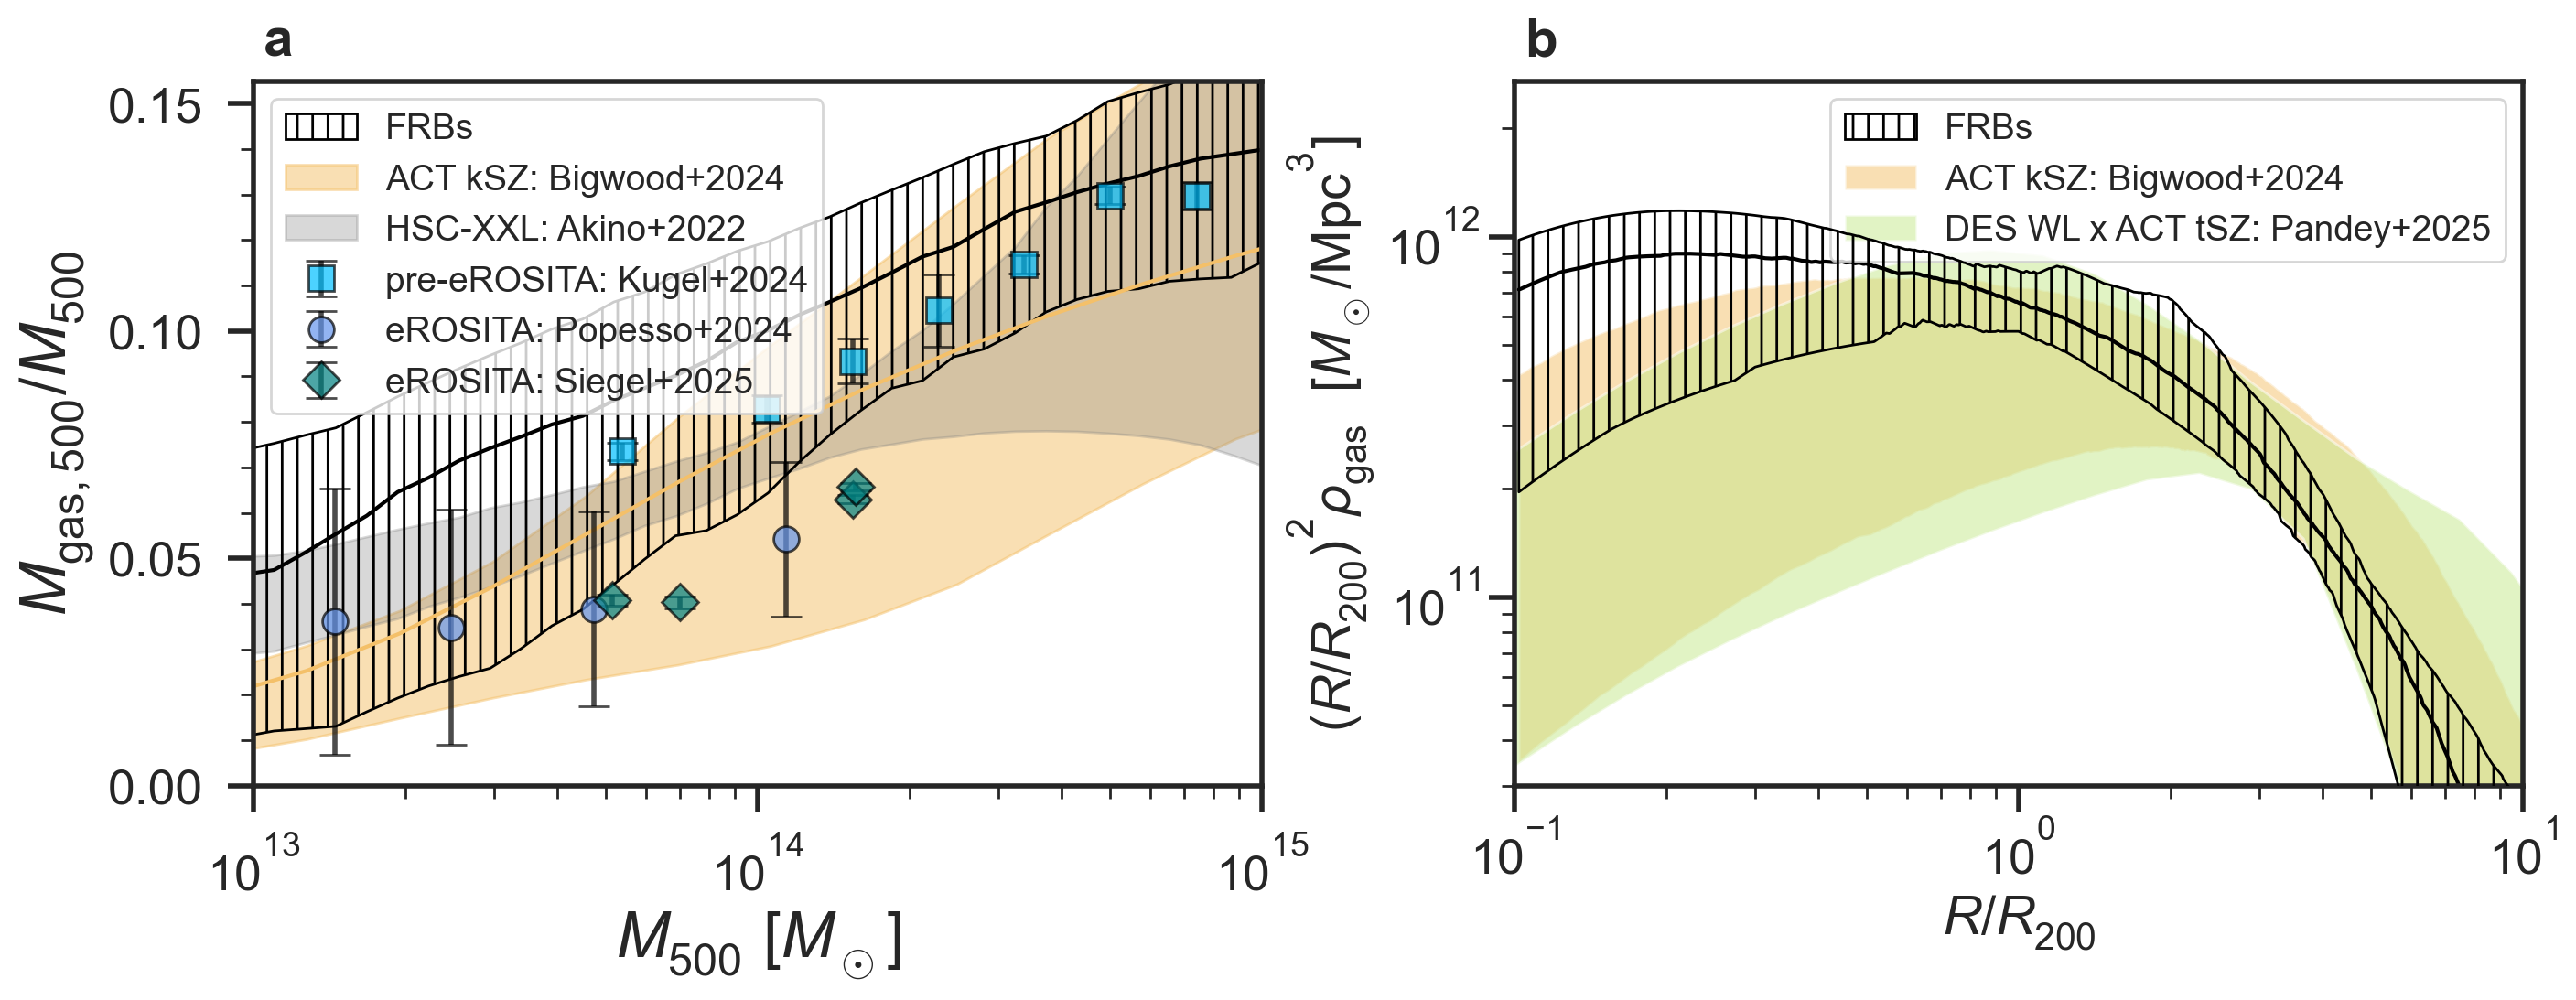

In [16]:
cmap = plt.get_cmap("rainbow")
colors = [cmap(i) for i in np.linspace(0, 1, 12)]

fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(16, 5))
plt.subplots_adjust(wspace=0.25)

ax2.fill_between(M500c, 
                 np.percentile(fgas_BCEmu5, 16, axis=0), 
                 np.percentile(fgas_BCEmu5, 84, axis=0), zorder=2,
                 facecolor='none', edgecolor='black', hatch='||', alpha=1, label="FRBs")
ax2.plot(M500c, np.percentile(fgas_BCEmu5, 50, axis=0), color='black')

m500, mean, lerr, uerr = np.loadtxt("data/literature_constraints/Bigwood_gasfrac.txt", skiprows=1, unpack=True)
ax2.fill_between(m500, lerr, uerr, color=colors[8], alpha=0.5, label="ACT kSZ: Bigwood+2024")
ax2.plot(m500, mean, color=colors[8])

kugel_m500 = (10**np.array([13.73099689692039, 14.018162142428746, 14.189014055125297, 14.358614305457769, 14.527784296852591, 14.699157735534174, 14.869996610081097]))
kugel_mean = np.array([0.07350477582749732, 0.08279072294273947, 0.0934022461699543, 0.10450567469058368, 0.1146302314325507, 0.12985065044103555, 0.12975187427769933])
kugel_err = np.array([0.002, 0.003, 0.005, 0.008, 0.002, 0.002, 0.003])


ax2.errorbar(kugel_m500, kugel_mean,
            yerr=[kugel_err, kugel_err],
            fmt="s", color='deepskyblue', ecolor='black', markeredgecolor="black",
            elinewidth=2, capsize=6, alpha=0.7, markersize=10, label="pre-eROSITA: Kugel+2024")

ax2.fill_between(M500c, akino_gasfrac_low, akino_gasfrac_high, color="gray", alpha=0.3, label="HSC-XXL: Akino+2022")

ax2.errorbar(Popesso_mass, Popesso_mean,
            yerr=[popesso_erru, popesso_erru],
            fmt="o", color='cornflowerblue', ecolor='black', markeredgecolor="black",
            elinewidth=2, capsize=6, alpha=0.7, markersize=10, label="eROSITA: Popesso+2024")

ax2.errorbar(jared_mass, jared_fgas,
            yerr=[jared_fgas_err, jared_fgas_err],
            fmt="D", color='teal', ecolor='black', markeredgecolor="black",
            elinewidth=2, capsize=6, alpha=0.7, markersize=10, label="eROSITA: Siegel+2025")

ax2.set_xlim(1e13, 1e15)
ax2.set_ylim(0, 0.155)
ax2.set_xscale('log')
ax2.set_ylabel(r'$M_\mathrm{gas,500}/M_\mathrm{500}$', size = 25)
ax2.set_xlabel(r'$M_{500}~[M_\odot]$', size = 25)
ax2.tick_params(pad = 10)

ax2.legend(fontsize=14, loc="upper left")

R200c = mdef.get_radius(cosmo_ccl, 1e14, 1)
ax1.fill_between(R/R200c,
                 np.percentile(gas_profiles["FRBs_1e14"][:, 0, :], 16, axis=0), 
                 np.percentile(gas_profiles["FRBs_1e14"][:, 0, :], 84, axis=0), zorder=10,
                 facecolor='none', edgecolor='black', hatch='||', alpha=1, label="FRBs")
ax1.plot(R/R200c, np.percentile(gas_profiles["FRBs_1e14"][:, 0, :], 50, axis=0), color='black')

ax1.fill_between(R/R200c, 
                 np.percentile(gas_profiles["kSZ_WL_1e14"][:, 0, :], 16, axis=0), 
                 np.percentile(gas_profiles["kSZ_WL_1e14"][:, 0, :], 84, axis=0), 
                 facecolor=colors[8], alpha=0.5, label="ACT kSZ: Bigwood+2024")

ax1.set_xlabel(r'$R/R_{\rm 200}$')
ax1.set_xscale('log'); ax1.set_yscale('log')

ax1.fill_between(data["r_array__Mpc_h"]/R200c/(cosmo.H0.value/100), 
                 data["x2_rho_{}_16th_percentile".format("1e14")], 
                 data["x2_rho_{}_84th_percentile".format("1e14")], 
                 facecolor=colors[7], alpha=0.5, label=r"DES WL x ACT tSZ: Pandey+2025")


ax1.set_xlim(0.1, 10); ax1.set_ylim(3e10, 2.7e12)
ax1.set_ylabel(r'$(R/R_{\rm 200})^2\rho_\mathrm{gas}$  $[M_\odot/{\rm Mpc}^3]$')
ax1.legend(loc="upper right", fontsize=14)

ax2.yaxis.set_major_locator(plt.MultipleLocator(0.05))
ax2.yaxis.set_minor_locator(plt.MultipleLocator(0.01))

ax1.text(0.01, 1.055, "b", ha='left', va='center', weight='bold', 
         transform=ax1.transAxes)
ax2.text(0.01, 1.055, "a", ha='left', va='center', weight='bold', 
         transform=ax2.transAxes)

plt.savefig('figures/fgas_rhogas.pdf', dpi=400, bbox_inches='tight')



In [17]:
idx = np.argmin(np.abs((R/R200c)-(ccl.halos.massdef.MassDef500c.get_radius(cosmo_ccl, 1e14, 1)/R200c)))
posterior_samples = np.array(gas_profiles["FRBs_1e14"][:, 0, idx])
posterior_samples2 = np.array(gas_profiles["kSZ_WL_1e14"][:, 0, idx])

mu1 = np.mean(posterior_samples)
mu2 = np.mean(posterior_samples2)

sigma1 = np.std(posterior_samples, ddof=1)
sigma2 = np.std(posterior_samples2, ddof=1)

tension_sigma = np.abs(mu1 - mu2) / np.sqrt(sigma1**2 + sigma2**2)

print(f"Tension = {tension_sigma:.2f} sigma")



Tension = 0.71 sigma


## Jackknife Resampling

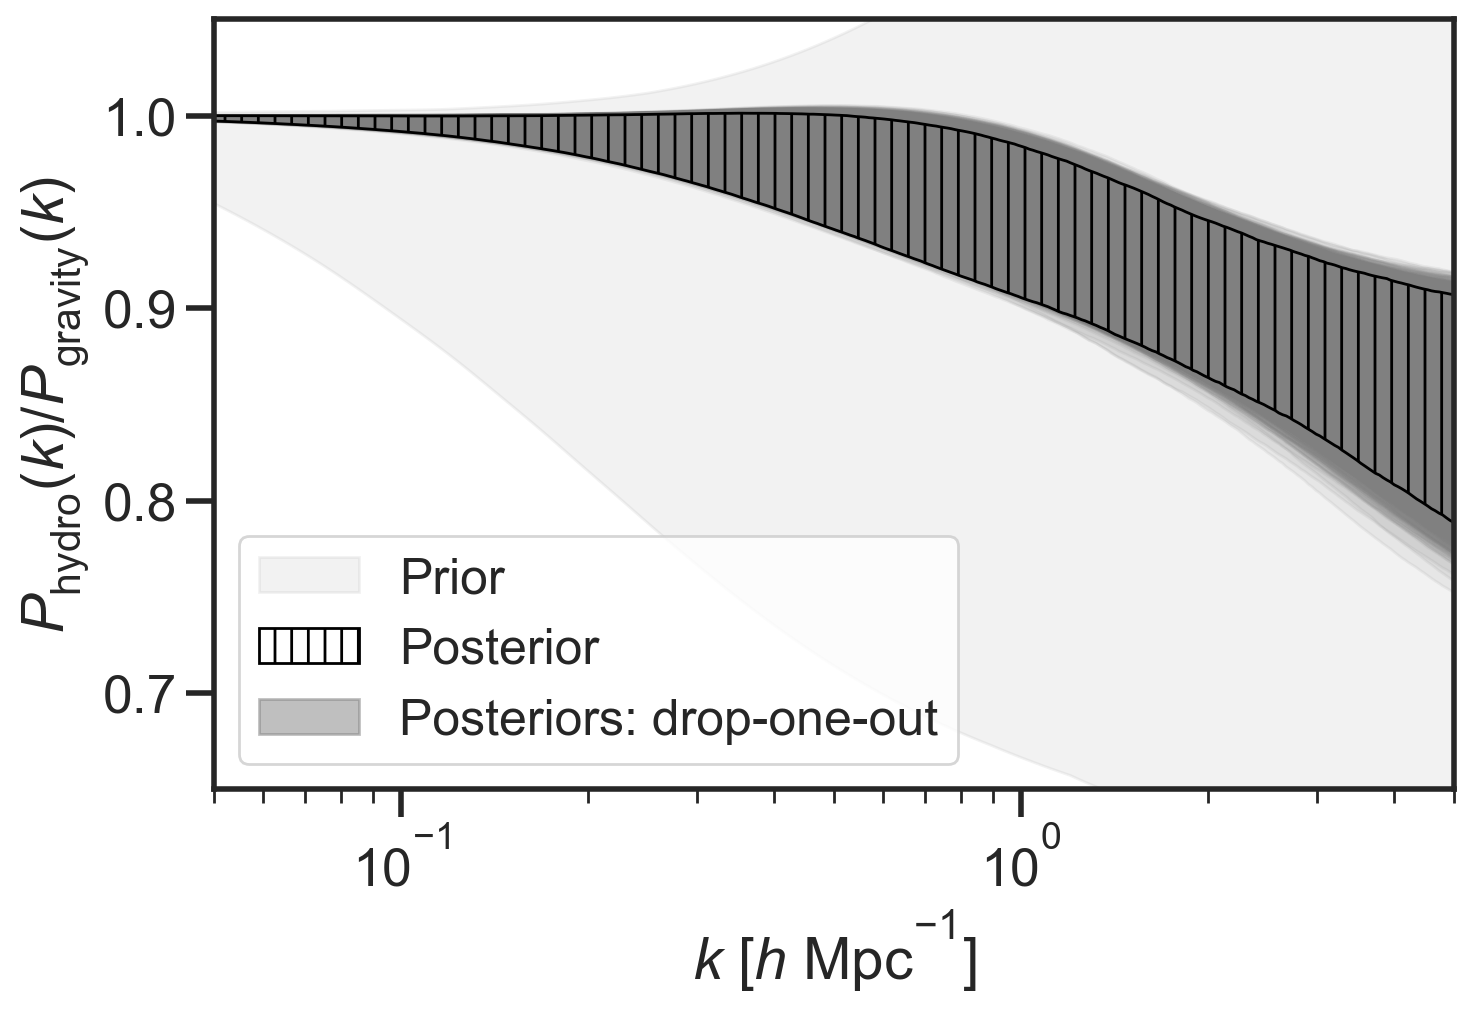

In [18]:
fig, axes = plt.subplots(1, 1, figsize=(8, 5), sharey=True)
plt.subplots_adjust(wspace=0.1)

axes.set_ylabel(r'$P_\mathrm{hydro}(k)/P_\mathrm{gravity}(k)$')
axes.set(xlim = [5e-2, 5], ylim=[0.65, 1.05], xscale='log', xlabel=r'$k$ $[h~\mathrm{Mpc}^{-1}]$')

ratio_spk_lo, ratio_spk_med, ratio_spk_hi = np.load('data/frb_results/prior/spk_BCEmu5_prior_fullrange_feedbackonly.npy')
axes.fill_between(k_fields/(cosmo.H0.value/100), ratio_spk_lo, ratio_spk_hi, color='gray', alpha=0.1, label="Prior")

for i in range(109):
         
    ratio_spk_lo, ratio_spk_med, ratio_spk_hi = np.load('data/frb_results/jacknife_sampling_tests/spk_BCEmu5_extended_Chandraprior_drop{}.npy'.format(i))
    axes.fill_between(k_fields/(cosmo.H0.value/100), ratio_spk_lo, ratio_spk_hi, color='gray', alpha=0.1)

ratio_spk_lo, ratio_spk_med, ratio_spk_hi = np.load('data/frb_results/spk_BCEmu5_extended_Chandraprior.npy')
axes.fill_between(k_fields/(cosmo.H0.value/100), ratio_spk_lo, ratio_spk_hi, facecolor='none', edgecolor='black', hatch='||', label="Posterior")

axes.fill_between([], [], [], color='gray', alpha=0.5, label="Posteriors: drop-one-out")

axes.legend(fontsize=18, loc="lower left")

plt.savefig('figures/drop_one_out_validation.pdf', dpi=400, bbox_inches='tight')
